In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import genextreme as gev

from unseen import eva
from unseen import stability

import utils

Matplotlib is building the font cache; this may take a moment.


In [2]:
# optional parameters
# (this cell is tagged "parameters")

metric = 'txx'
location = [4, 1]
model_dict = {
    'BCC-CSM2-MR': '#ffffb3',
    'CAFE': '#66c2a5',
    'CMCC-CM2-SR5': '#80b1d3',
    'CanESM5': '#fdb462',
    'EC-Earth3': '#b3de69',
    'IPSL-CM6A-LR': '#fccde5',
    'MIROC6': '#d9d9d9',
    'MPI-ESM1-2-HR': '#bc80bd',
    'MRI-ESM2-0': '#fc8d62',
    'NorCPM1': '#8da0cb',
}  

In [3]:
assert "location" in locals(), "Must provide a location name"
assert "metric" in locals(), "Must provide a metric (rx1day or txx)"
assert "model_dict" in locals(), "Must provide a model dict"

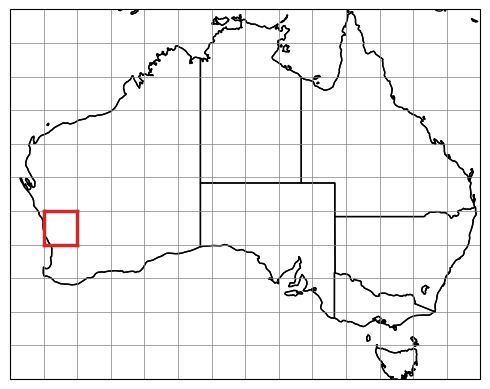

In [4]:
if type(location) == list:
    lat_index, lon_index = location
    utils.plot_grid_box(lat_index, lon_index)

## Analysis

In [5]:
def get_data(metric, location, model_dict):
    """Get data."""
    
    return_values_dict = {}
    gev_params_dict = {}
    sample_size_dict = {}

    da_obs = utils.get_obs_data(metric, location)
    da_obs_detrended, linear_data_obs = utils.detrend_obs(da_obs)
    gev_params_obs_detrended = list(eva.fit_gev(da_obs_detrended.values))
    return_periods, return_values_obs = stability.return_curve(
        da_obs_detrended,
        'gev',
        params=gev_params_obs_detrended,
    )
    return_values_dict[('obs', 'AGCD')] = return_values_obs
    
    for model in model_dict:
        print(model)
        da_model_stacked = utils.get_model_data(metric, model, location)
        da_model_detrended, da_model_detrended_stacked, linear_data_model = utils.detrend_model(da_model_stacked)
        da_model_detrended_stacked_bc_mean = utils.mean_correction(da_model_detrended, da_obs_detrended, metric)
        da_model_detrended_stacked_bc_quantile = utils.quantile_correction(da_model_detrended_stacked, da_obs_detrended, metric)
        gev_model_detrended = list(eva.fit_gev(da_model_detrended_stacked.values))
        gev_model_detrended_bc_mean = list(eva.fit_gev(da_model_detrended_stacked_bc_mean.values))
        gev_model_detrended_bc_quantile = list(eva.fit_gev(da_model_detrended_stacked_bc_quantile.values))
        return_periods, return_values_model_raw = stability.return_curve(
            da_model_detrended_stacked,
            'gev',
            params=gev_model_detrended,
        )
        return_periods, return_values_model_bc_mean = stability.return_curve(
            da_model_detrended_stacked_bc_mean,
            'gev',
            params=gev_model_detrended_bc_mean,
        )
        return_periods, return_values_model_bc_quantile = stability.return_curve(
            da_model_detrended_stacked_bc_quantile,
            'gev',
            params=gev_model_detrended_bc_quantile,
        )
        return_values_dict[('model-raw', model)] = return_values_model_raw
        return_values_dict[('model-bc-mean', model)] = return_values_model_bc_mean
        gev_params_dict[('model-bc-mean', model)] = gev_model_detrended_bc_mean
        sample_size_dict[('model-bc-mean', model)] = len(da_model_detrended_stacked_bc_mean.values)
        return_values_dict[('model-bc-quantile', model)] = return_values_model_bc_quantile

    return_values_df = pd.DataFrame(return_values_dict)
    return_values_df.index = return_periods
    return_values_df = return_values_df.drop([1.0])
    
    return return_values_df, gev_params_dict, sample_size_dict

In [6]:
def plot_dataset_uncertainty(
    ax,
    metric,
    model_dict,
    return_df,
    ylim=[],
    outfile=None,
):
    """Plot dataset uncertainty."""

    return_periods = return_df.index.values
    
    for model, color in model_dict.items():
        ax.plot(
            return_periods,
            return_df[('model-bc-mean', model)].values,
            label=f'{model}',
            color=color,
            linewidth=3.0,
        )
    
    ax.legend()#bbox_to_anchor=(legend_offset, 0.5), loc='center right')
    ax.set_xscale('log')
    ax.set_xlabel('return period (years)')
    ax.set_ylabel(' ')
    ax.set_title('(c) dataset uncertainty')
    if ylim:
        ax.set_ylim(ylim)
    ax.grid(which='both')

In [7]:
def plot_bias_correction_uncertainty(
    ax,
    metric,
    model_dict,
    return_df,
    ylim=[],
    outfile=None,
):
    """Plot return curves."""

    return_periods = return_df.index.values
    
    for model, color in model_dict.items():
        ax.plot(
            return_periods,
            return_df[('model-bc-mean', model)].values,
            label=f'{model} (mean)',
            color=color,
            linewidth=3.0,
        )
        ax.plot(
            return_periods,
            return_df[('model-bc-quantile', model)].values,
            label=f'{model} (quantile)',
            color=color,
            linestyle='--',
            linewidth=3.0,
        )
        
    ax.plot(
            return_periods,
            return_df[('obs', 'AGCD')].values,
            label='AGCD',
            color='black',
            linewidth=3.0,
        )
    
    ax.legend()#bbox_to_anchor=(legend_offset, 0.5), loc='center right')
    ax.set_xscale('log')
    ax.set_xlabel('return period (years)')
    ax.set_ylabel(' ')
    ax.set_title('(b) bias correction uncertainty')
    if ylim:
        ax.set_ylim(ylim)
    ax.grid(which='both')

In [11]:
def plot_eva_uncertainty(
    ax,
    metric,
    model_dict,
    gev_params_dict,
    sample_size_dict,
    ylim=[],
    n_bootstraps=10,
    outfile=None,
):
    """PLot sampling uncertainty."""

    return_periods = return_df.index.values
    
    for model, color in model_dict.items():
        original_gev_params = gev_params_dict[('model-bc-mean', model)]
        shape, loc, scale = original_gev_params
        sample_size = sample_size_dict[('model-bc-mean', model)]
        for i in range(n_bootstraps):
            boot_data = gev.rvs(shape, loc=loc, scale=scale, size=sample_size)
            boot_gev_params = list(eva.fit_gev(boot_data))
            return_periods, return_values = stability.return_curve(boot_data, 'gev', params=boot_gev_params)
            label = model if i == 0 else None
            ax.plot(return_periods, return_values, label=label, color=color, linewidth=3.0)

    ax.legend()#bbox_to_anchor=(legend_offset, 0.5), loc='center right')
    ax.set_xscale('log')
    ax.set_xlabel('return period (years)')
    ax.set_ylabel('TXx ($^\circ$C)')
    ax.set_title('(a) sampling uncertainty')
    if ylim:
        ax.set_ylim(ylim)
    ax.grid(which='both')

## Plots

In [9]:
return_df, gev_params_dict, sample_size_dict = get_data(metric, location, model_dict)

BCC-CSM2-MR
CAFE
CMCC-CM2-SR5
CanESM5
EC-Earth3
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MRI-ESM2-0
NorCPM1


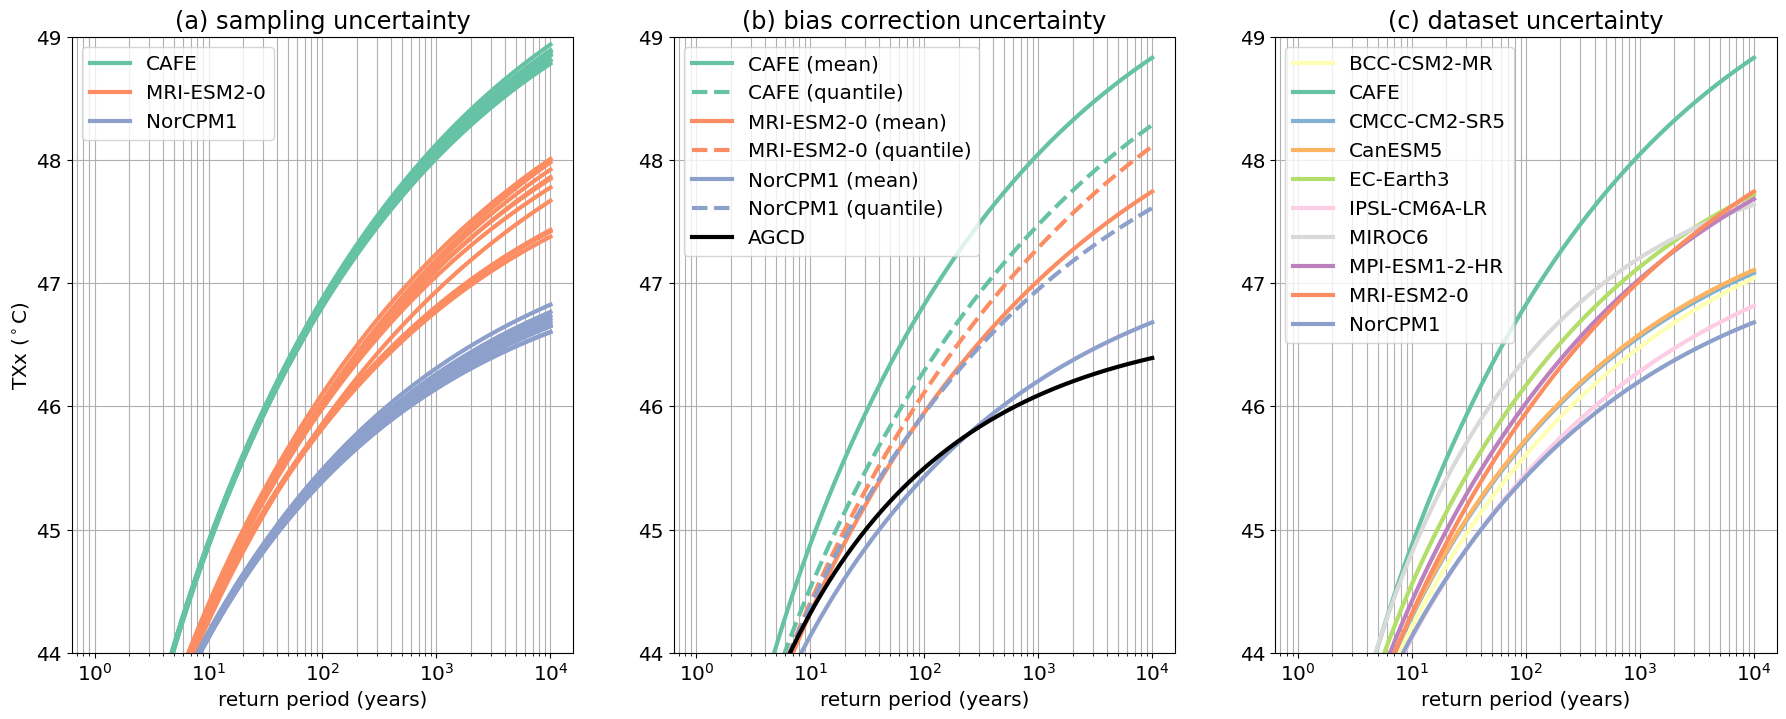

In [12]:
fig = plt.figure(figsize=[22, 8])

ylim = [44, 49]
model_subset = ['CAFE', 'MRI-ESM2-0', 'NorCPM1']

ax1 = fig.add_subplot(131)
eva_model_dict = {key: model_dict[key] for key in model_subset if key in model_dict}
plot_eva_uncertainty(
    ax1,
    metric,
    eva_model_dict,
    gev_params_dict,
    sample_size_dict,
    ylim=ylim,
    n_bootstraps=10,
    outfile=None,
)

ax2 = fig.add_subplot(132)
bias_model_dict = {key: model_dict[key] for key in model_subset if key in model_dict}
plot_bias_correction_uncertainty(
    ax2,
    metric,
    bias_model_dict,
    return_df,
    ylim=ylim,
    outfile=None,
)

ax3 = fig.add_subplot(133)
plot_dataset_uncertainty(
    ax3,
    metric,
    model_dict,
    return_df,
    ylim=ylim,
    outfile=None,
)

plt.savefig('figures/uncertainty_demo.png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()